<a href="https://colab.research.google.com/github/A-Peoples/NFL_Team_Penalties/blob/main/Penalty_Chart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Importing Datasets**

In [ ]:
!pip install sportsdataverse
!pip install xgboost==1.6.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.6/19.6 MB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 277.1/277.1 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 776.2/776.2 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 14.9 MB/s eta 0:00:00
  Attempting uninstall: polars
    Found existing installation: polars 1.35.2
    Uninstalling polars-1.35.2:
      Successfully uninstalled polars-1.35.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 255.9/255.9 MB 5.1 MB/s eta 0:00:00
  Attempting uninstall: xgboost
    Found existing installation: xgboost 3.2.0
    Uninstalling xgboost-3.2.0:
      Successfully uninstalled xgboost-3.2.0


In [ ]:
#importing packages
import pandas as pd
import sportsdataverse as sdv
import numpy as np
import os
import urllib.request
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from scipy.stats import t

In [ ]:
pbp = sdv.nfl.load_nfl_pbp((range(2016, 2025+1)), return_as_pandas=True)
roster_pre_25 = sdv.nfl.load_nfl_rosters(range(2016, 2024+1), return_as_pandas=True)
roster_2025 = sdv.nfl.load_nfl_rosters([2025], return_as_pandas=True)

roster = pd.concat([roster_pre_25, roster_2025])
colors = sdv.nfl.load_nfl_teams(return_as_pandas=True)

100%|██████████| 1/1 [00:00<00:00,  4.81it/s]


In [ ]:
age = roster.groupby(['season', 'team']).agg({"years_exp": 'mean'}).reset_index()

age.sort_values(by="years_exp", ascending=False)

age.to_csv("team_age.csv")

In [ ]:
age['season'].unique()

<ArrowExtensionArray>
[2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Length: 10, dtype: int32[pyarrow]

In [ ]:
#pbp_penalty = pbp.loc[pbp['penalty'] > 0]
#pbp_nopenalty = pbp.loc[pbp['penalty'] == 0]
#pbp_penalty['penalty_off'] = np.where(pbp_penalty['penalty_team'] == pbp_penalty['posteam'], 1 ,0)
#pbp_penalty['penalty_def'] = np.where(pbp_penalty['penalty_team'] == pbp_penalty['defteam'], 1 ,0)

**columns that could be used: "penalty", "first_down_penalty", 'penalty_team', 'penalty_player_id', 'penalty_player_name', "penalty_type", "penalty_yards"**

# **Part 1: Before Streamlit**

In [ ]:
team_list = pbp['penalty_team'].unique().tolist()

def team_search():
  global filt_team
  filt_team_loop = 0
  display_list = (f"{team_list[1:10]}\n"
                  f"{team_list[11:21]}\n"
                  f"{team_list[22:32]}"
                  )
  while filt_team_loop < 0.1:
    filt_team = input('Choose a team to filter for:\nTeams: ' + display_list + ": ")
    if filt_team in str(team_list):
      filt_team_loop = 1
    else:
      print("Error. Enter a team in list.\n")
  global pbp_team_filt
  pbp_team_filt = pbp.loc[((pbp['home_team'] == filt_team) | (pbp['away_team'] == filt_team)) & (pbp['penalty_team'] == filt_team)]
  global pbp_filt
  pbp_filt = pbp.loc[((pbp['home_team'] == filt_team) | (pbp['away_team'] == filt_team))]
  #print("Filter Successful\n")

In [ ]:
def penalty_year_chart():
  global team_pen
  global avg_pen
  team_pen = pbp_team_filt.groupby(['penalty_team', 'season']).agg({'penalty': ['count'],
                                                        }).reset_index()

  avg_pen = pbp_filt.groupby(['season']).agg({'penalty': ['count'],
                                                        }).reset_index()
  avg_pen['penalty'] = avg_pen['penalty'] / 32
  avg_pen = avg_pen.rename(columns={'penalty_team_': "penalty_team",
                                      'season_': "season"})

  team_pen.columns = list(map("_".join, team_pen.columns))
  team_pen = team_pen.rename(columns={'penalty_team_': "penalty_team",
                                      'season_': "season"})


  plt.plot(avg_pen['season'], avg_pen['penalty'], color='gray')
  plt.plot(team_pen['season'], team_pen['penalty_count'])
  plt.legend(['League Average', filt_team])
  plt.xlabel('Season')
  plt.ylabel('Penalties')
  plt.title(filt_team + " Team Penalties from 2016-2025")
  print("**" + filt_team + " Team Penalties from 2016-2025**\n")
  plt.show()

In [ ]:
def penalty_type_chart():
  global pen_type
  global filt_team
  global year_filt
  pen_type = pbp.groupby(['penalty_team', 'season', 'penalty_type']).agg({'penalty': 'count'}).reset_index()

  year_filt = 2025

  #pen_type = pen_type.loc[(pen_type['season'] == year_filt) & (pen_type['penalty'] > 1)]
  pen_type = pen_type.sort_values(by="penalty", ascending=True)
  plt.barh(pen_type['penalty_type'], pen_type['penalty'])
  plt.xlabel('Total Penalties')
  plt.ylabel('Penalty Type')
  plt.title(filt_team + " Team Penalties from " + str(year_filt))
  print("\n**" + filt_team + " Team Penalties from " + str(year_filt) + '**\n')
  plt.show()

In [ ]:
def penalty_player_team_chart():
  global pen_person
  global pen_person_filt
  pen_person = pbp.groupby(['penalty_player_name', 'penalty_player_id', 'season', 'penalty_team']).agg({'penalty': 'count'}).reset_index()
  pen_person = pen_person.loc[(pen_person['penalty_team'] == filt_team) & (pen_person['season'] == year_filt)]
  pen_person = pen_person.drop_duplicates(subset=['penalty_player_id'])
  pen_person = pen_person.sort_values(by="penalty", ascending=False).reset_index()
  pen_person_filt = pen_person.head(20)
  pen_person_filt = pen_person_filt[::-1]
  pen_person = pen_person.loc[(pen_person['penalty_player_id'].isin(roster['gsis_id']))]
  plt.barh(pen_person_filt['penalty_player_name'], pen_person_filt['penalty'])
  pen_person_filt = pen_person_filt[::-1]
  plt.xlabel('Total Penalties')
  plt.ylabel('Player')
  plt.title(filt_team + " Top 20 Player Penalties from " + str(year_filt))
  print('\n**' + filt_team + " Top 20 Player Penalties from " + str(year_filt) + '**\n')
  plt.show()

In [ ]:
pen_person = pbp.groupby(['penalty_player_name', 'penalty_player_id', 'season', 'penalty_team']).agg({'penalty': 'count'}).reset_index()

pen_person.to_csv("pen_person.csv")

In [ ]:
def pos_penalties_chart():
  fig, ax = plt.subplots()
  global pen_person
  player_lists = list(pen_person['penalty_player_id'])

  roster_filt = roster.loc[(roster['gsis_id'].isin(pen_person['penalty_player_id'])) & (roster['season'] == year_filt)]
  pen_person = pen_person.loc[(pen_person['penalty_player_id'].isin(roster['gsis_id']))]

  roster_filt = roster_filt[['gsis_id', 'position', 'depth_chart_position', 'headshot_url', 'full_name']]
  roster_filt = roster_filt.rename(columns={'gsis_id': 'penalty_player_id'})
  roster_filt_merge = pen_person.merge(roster_filt, on='penalty_player_id', how='left')
  pos_pen = roster_filt_merge.groupby(['depth_chart_position']).agg({'penalty': sum}).reset_index()
  pos_pen = pos_pen.sort_values(by="penalty", ascending=True).reset_index()
  ax.barh(pos_pen['depth_chart_position'], pos_pen['penalty'])
  ax.set_xlabel('Total Penalties')
  ax.set_ylabel('Position')
  ax.set_title(filt_team + " Overall Position Penalties from " + str(year_filt))
  print('\n**' + filt_team + " Overall Position Penalties from " + str(year_filt) + '**\n')
  plt.show()

In [ ]:
team_age = roster.groupby(['team', 'season']).agg({'years_exp': 'mean'}).reset_index()
team_age.to_csv("team_age.csv")

In [ ]:
penalty_count = pbp.groupby(['penalty_team', 'season']).agg({"penalty_yards": 'sum',
                                                    'penalty': 'sum',
                                                    'first_down_penalty': 'sum'}).reset_index()
penalty_count['years_exp'] = team_age['years_exp']
penalty_count.to_csv("penalty_count.csv")

Choose a team to filter for:
Teams: ['BAL', 'BUF', 'CAR', 'DEN', 'CHI', 'HOU', 'CIN', 'NYJ', 'CLE']
['DET', 'IND', 'JAX', 'GB', 'LA', 'SF', 'SEA', 'MIA', 'MIN', 'TEN']
['NE', 'DAL', 'NYG', 'LV', 'NO', 'WAS', 'PIT', 'KC', 'LAC', 'ATL']: ATL
**ATL Team Penalties from 2016-2025**



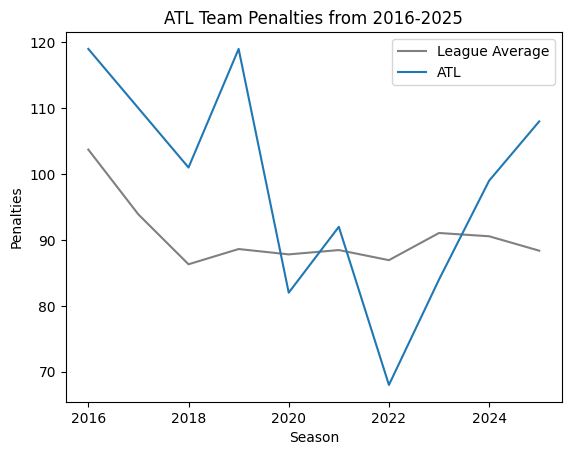


**ATL Team Penalties from 2025**



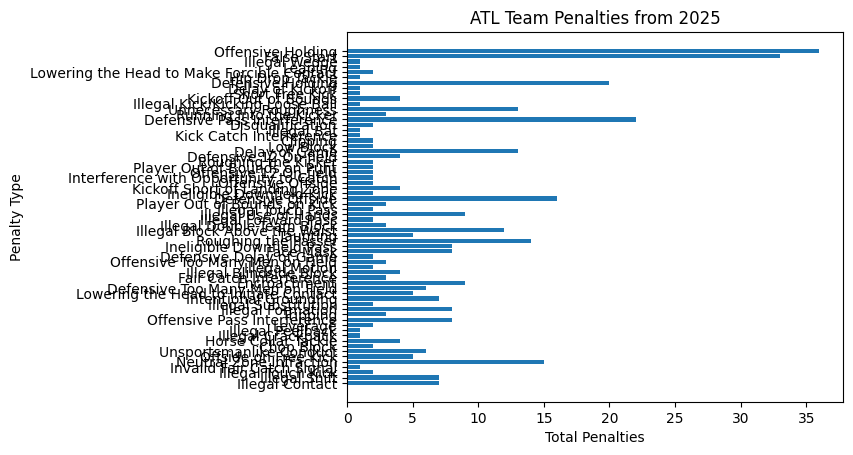


**ATL Top 20 Player Penalties from 2025**



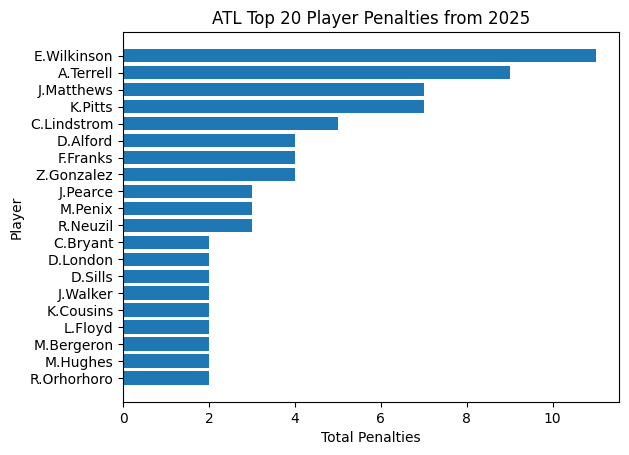


**ATL Overall Position Penalties from 2025**



/tmp/ipykernel_706/174772412.py:12: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  pos_pen = roster_filt_merge.groupby(['depth_chart_position']).agg({'penalty': sum}).reset_index()


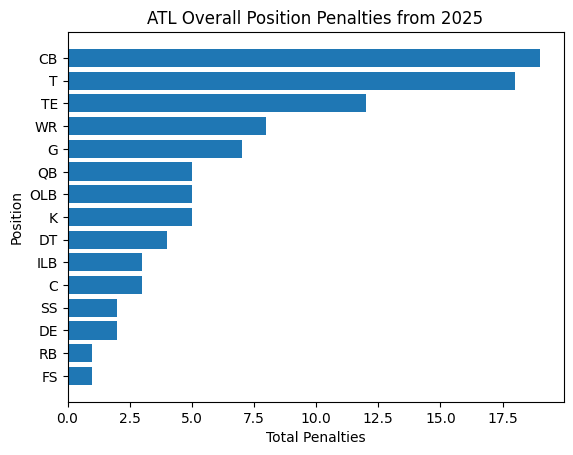

In [ ]:
team_search()
penalty_year_chart()
penalty_type_chart()
penalty_player_team_chart()
pos_penalties_chart()

In [ ]:
coach_list = pbp.groupby(["home_coach", "home_team", 'season']).agg({'play_id': "count"}).reset_index()[["home_coach", "home_team", 'season']]

coach_list

,home_coach,home_team,season
0,Aaron Glenn,NYJ,2025
1,Adam Gase,MIA,2016
2,Adam Gase,MIA,2017
3,Adam Gase,MIA,2018
4,Adam Gase,NYJ,2019
...,...,...,...
331,Zac Taylor,CIN,2021
332,Zac Taylor,CIN,2022
333,Zac Taylor,CIN,2023
334,Zac Taylor,CIN,2024


/tmp/ipykernel_706/116204383.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  penalty_yards_16[['penalty_yards', 'yards_gained']] = penalty_yards_16[['penalty_yards', 'yards_gained']] / (256 * 2)
/tmp/ipykernel_706/116204383.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  penalty_yards_16['yards_lost'] = penalty_yards_16['penalty_yards'] / penalty_yards_16['yards_gained']
/tmp/ipykernel_706/116204383.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Tr

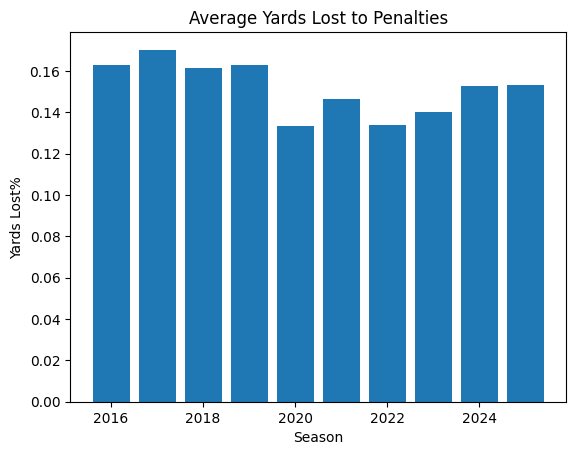

In [ ]:
penalty_yards = pbp.groupby("season").agg({'penalty_yards': 'sum',
                                           'yards_gained': 'sum',

                                           }).reset_index()

penalty_yards_16 = penalty_yards.loc[penalty_yards['season'] < 2020.9]
penalty_yards_16[['penalty_yards', 'yards_gained']] = penalty_yards_16[['penalty_yards', 'yards_gained']] / (256 * 2)
penalty_yards_16['yards_lost'] = penalty_yards_16['penalty_yards'] / penalty_yards_16['yards_gained']
penalty_yards_16

penalty_yards_17 = penalty_yards.loc[penalty_yards['season'] > 2020.9]
penalty_yards_17[['penalty_yards', 'yards_gained']] = penalty_yards_17[['penalty_yards', 'yards_gained']] / (256 * 2)
penalty_yards_17['yards_lost'] = penalty_yards_17['penalty_yards'] / penalty_yards_17['yards_gained']
penalty_yards_17

penalty_yards = pd.concat([penalty_yards_16, penalty_yards_17])

penalty_yards
plt.bar(penalty_yards['season'], penalty_yards['yards_lost'])
plt.xlabel('Season')
plt.ylabel('Yards Lost%')
plt.title("Average Yards Lost to Penalties")
#plt.style.use("dark_background")
plt.show()

(array([10357.,     0.,     0.,  7602.,     0.,     0.,  4655.,     0.,
            0.,  2434.]),
 array([1. , 1.3, 1.6, 1.9, 2.2, 2.5, 2.8, 3.1, 3.4, 3.7, 4. ]),
 <BarContainer object of 10 artists>)

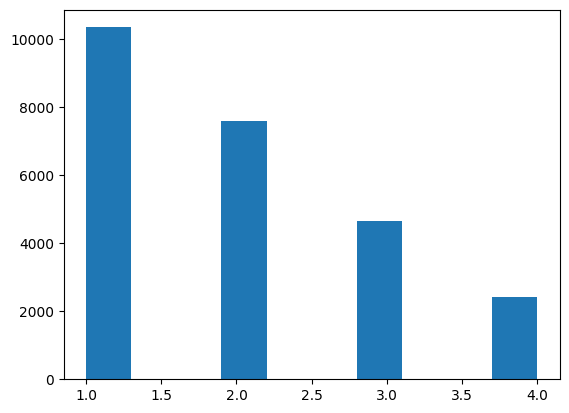

In [ ]:
plt.hist(pbp_filt['down'])

In [ ]:
#y = roster.groupby(["season", 'team']).agg({"years_exp": "mean"}).reset_index().sort_values(by="team", ascending=True)
x = pd.read_csv("https://raw.githubusercontent.com/A-Peoples/NFL_Team_Penalties/refs/heads/main/penalty_count.csv")
#y['Unnamed: 0'] = x['Unnamed: 0']
#z = x.merge(y, on='Unnamed: 0')

#z = z[['penalty_team', 'season_x', 'penalty_yards', 'penalty', 'first_down_penalty', 'years_exp']]

#z = z.sort_values(by="penalty", ascending=False)

#z = z.rename(columns={"season_x": "season"})
#z.head(10)
#z.to_csv("penalty_count.csv")

In [ ]:
x = pd.read_csv("https://raw.githubusercontent.com/A-Peoples/NFL_Team_Penalties/refs/heads/main/penalty_count.csv")
y = pd.read_csv("https://raw.githubusercontent.com/A-Peoples/NFL_Team_Penalties/refs/heads/main/standings.csv")

Text(0, 0.5, 'Penalty Count')

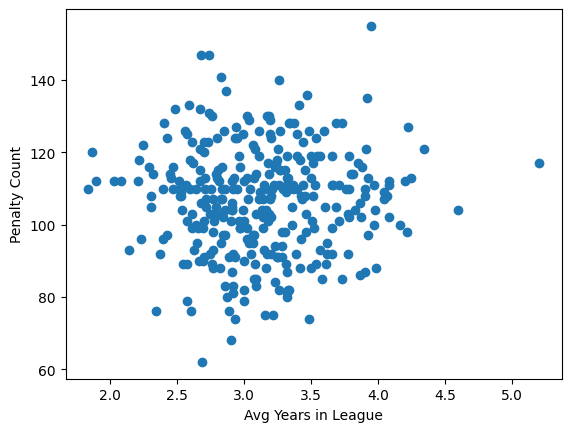

In [ ]:
x['W-L%'] = y['W-L%']
plt.scatter(x['years_exp'], x['penalty'])
plt.xlabel("Avg Years in League")
plt.ylabel("Penalty Count")

In [ ]:
xy = colors[['team_name', 'team_abbr']]#, 'season']]
names = xy.loc[xy['team_abbr'].isin(team_list)].reset_index()

names.to_csv('names.csv')

# **Part 2: After Streamlit**

In [ ]:
age = pd.read_csv("https://raw.githubusercontent.com/A-Peoples/NFL_Team_Penalties/refs/heads/main/penalty_count.csv")

In [ ]:
age_inflated = age.loc[age['season'] <= 2021]
age_noninflated = age.loc[age['season'] > 2021]

age_inflated['penalty'] = age_inflated['penalty'] * 1.0588

age_int = pd.concat([age_inflated, age_noninflated])

/tmp/ipykernel_706/1880089318.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  age_inflated['penalty'] = age_inflated['penalty'] * 1.0588


Text(0.5, 1.0, 'Avg League Years ~ Penalty Count (>2021 Penalties Inflated)')

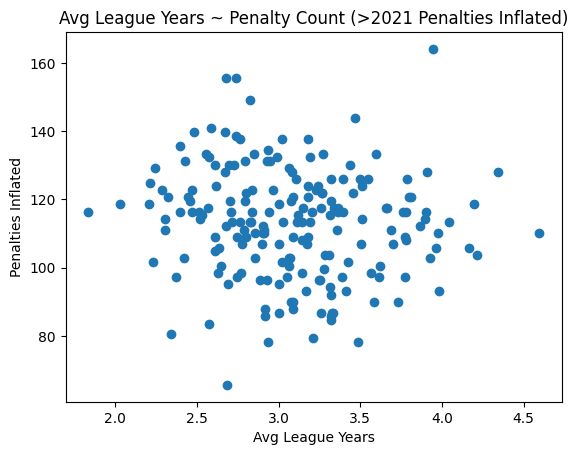

In [ ]:
plt.scatter(age_inflated['years_exp'], age_inflated['penalty'])
plt.xlabel('Avg League Years')
plt.ylabel('Penalties Inflated')
plt.title('Avg League Years ~ Penalty Count (>2021 Penalties Inflated)')

Text(0.5, 1.0, 'Avg League Years ~ Penalty Count')

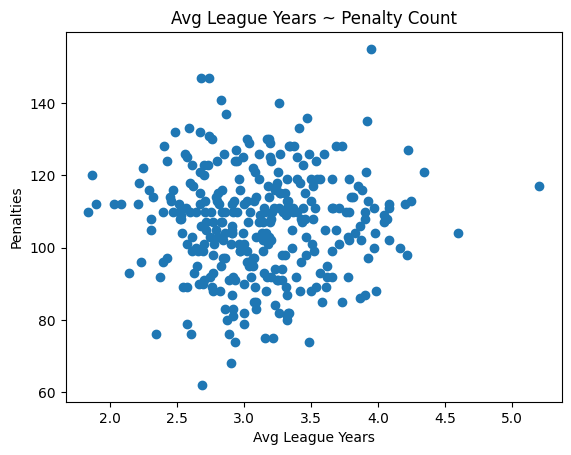

In [ ]:
plt.scatter(age['years_exp'], age['penalty'])
plt.xlabel('Avg League Years')
plt.ylabel('Penalties')
plt.title('Avg League Years ~ Penalty Count')

In [ ]:
penalty_pbp = pbp.loc[pbp['penalty'] == 1]

penalty_pbp['penalty'].unique()

pen_type = penalty_pbp.groupby(['penalty_team', 'season', 'penalty_type']).agg({"penalty": 'sum'})

pen_type.reset_index()

pen_type.to_csv("pen_type.csv")

In [ ]:
age =  pd.read_csv("https://raw.githubusercontent.com/A-Peoples/NFL_Team_Penalties/refs/heads/main/penalty_count.csv")
standings =  pd.read_csv("https://raw.githubusercontent.com/A-Peoples/NFL_Team_Penalties/refs/heads/main/standings.csv")

In [ ]:
pen_int = age['years_exp'].corr(age['penalty'])
pen_int_inf = age_inflated['years_exp'].corr(age_inflated['penalty'])

print('Years Played Correlation with Penalty Count: ' + str(pen_int) + "\nYears Played Correlation with Inflated Penalty Count: " + str(pen_int_inf))

Years Played Correlation with Penalty Count: 0.02370237814283971
Years Played Correlation with Inflated Penalty Count: -0.1060534547556639


In [ ]:
age['W-L%'] = standings['W-L%']
age['PtDif'] = standings['PtDif']

pen_int = age['years_exp'].corr(age['W-L%'])

#print('Years Played Correlation with Win-Loss: ' + str(pen_int))

age = age.sort_values(by='penalty', ascending=False)

age['season'].unique()

array([2016, 2017, 2018, 2021, 2024, 2025, 2019, 2023, 2020, 2022])

Text(0.5, 1.0, 'Top 15 Penalties in NFL')

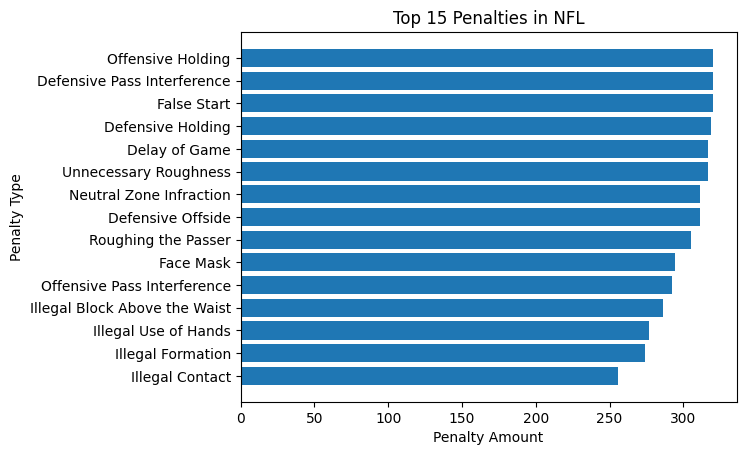

In [ ]:
pen_type = pd.read_csv("https://raw.githubusercontent.com/A-Peoples/NFL_Team_Penalties/refs/heads/main/pen_type.csv")

pen_type = pen_type.groupby(['penalty_type']).agg({"penalty":"count"}).reset_index()
pen_type = pen_type.sort_values(by="penalty", ascending=False)

pen_type_chart = pen_type.head(15)
pen_type_chart = pen_type_chart.sort_values(by="penalty", ascending=True)
pen_type_chart

plt.barh(pen_type_chart['penalty_type'], pen_type_chart['penalty'])
plt.xlabel("Penalty Amount")
plt.ylabel("Penalty Type")
plt.title("Top 15 Penalties in NFL")

Text(0.5, 1.0, ' Penalties Commited by Every Team')

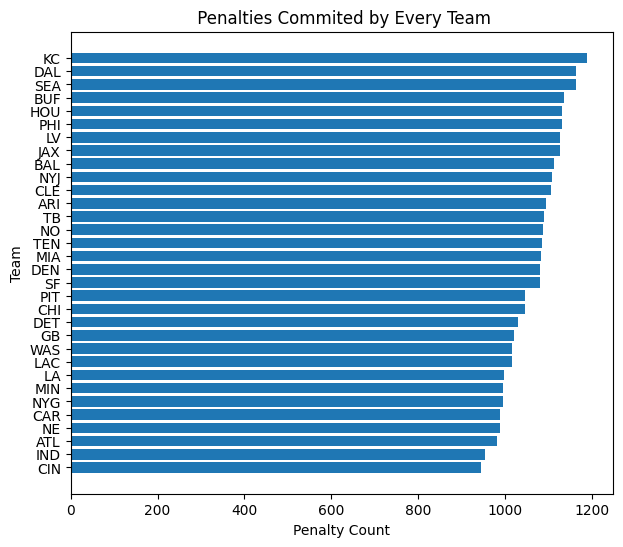

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
pen_count = age.groupby(['penalty_team']).agg({"penalty": 'sum'}).reset_index()
pen_count = pen_count.sort_values(by="penalty", ascending=True).reset_index()
plt.barh(pen_count['penalty_team'], pen_count['penalty'])
plt.ylabel("Team")
plt.xlabel("Penalty Count")
plt.title(" Penalties Commited by Every Team")

In [ ]:
pbp_penalty = pbp.loc[(pbp['penalty'] > 0) & (~pbp['penalty'].isnull())]

In [ ]:
pen_type_count = pbp_penalty[['penalty_team', 'penalty_player_name', 'penalty_player_id', 'penalty_type', 'season']]

In [ ]:
roster_filt = roster.loc[(roster['gsis_id'].isin(list(pen_type_count['penalty_player_id']))) &
                         (~roster['gsis_id'].isnull())]

roster_filt = roster_filt[['full_name', 'season', 'gsis_id', 'years_exp']]
#roster_filt = roster_filt.rename(columns={'full_name': 'penalty_player_name'})
roster_filt = roster_filt.rename(columns={'gsis_id': 'penalty_player_id'})

In [ ]:
#def player_match(row):

#  team_match = roster_filt[
#    (roster_filt['penalty_player_id'] == row['penalty_player_id']) &
#   (roster_filt['season'] == row['season'])
#   ]
#  if not team_match.empty:
#    return team_match['years_exp'].iloc[0]
#  return None
#pen_type_count['penalty_player_year_exp'] = pen_type_count.apply(player_match, axis=1)

In [ ]:
pen_type_count_merge = pd.merge(roster_filt, pen_type_count,
                                            on=['season', 'penalty_player_id'],
                                            how='left')

pen_type_count_merge = pen_type_count_merge.loc[(~pen_type_count_merge['years_exp'].isnull()) &
                                                (~pen_type_count_merge['penalty_type'].isnull())]

pen_type_count_merge = pen_type_count_merge[['full_name', 'penalty_player_name', 'penalty_player_id', 'penalty_team', 'season', 'years_exp', 'penalty_type']]

pen_type_count_merge.to_csv("pen_type_count.csv")

pen_type_count_merge

,full_name,penalty_player_name,penalty_player_id,penalty_team,season,years_exp,penalty_type
0,Tom Brady,T.Brady,00-0019596,NE,2016,16,Intentional Grounding
1,Tom Brady,T.Brady,00-0019596,NE,2016,16,Intentional Grounding
2,Shane Lechler,S.Lechler,00-0019714,HOU,2016,16,Delay of Game
8,Drew Brees,D.Brees,00-0020531,NO,2016,15,Intentional Grounding
9,Drew Brees,D.Brees,00-0020531,NO,2016,15,Delay of Game
...,...,...,...,...,...,...,...
40612,Will Johnson,W.Johnson,00-0040751,ARI,2025,0,Face Mask
40613,Will Johnson,W.Johnson,00-0040751,ARI,2025,0,Illegal Use of Hands
40614,Will Johnson,W.Johnson,00-0040751,ARI,2025,0,Illegal Contact
40615,Will Johnson,W.Johnson,00-0040751,ARI,2025,0,Defensive Holding


/tmp/ipykernel_706/2084952904.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm = plt.cm.get_cmap('Blues_r')


Text(0.5, 1.0, 'Penalty Count by Years Played in NFL')

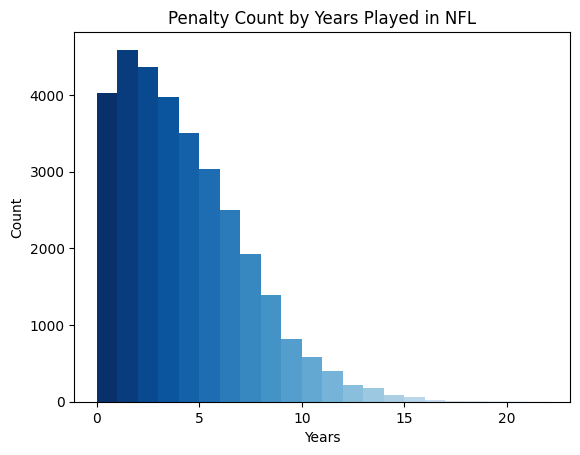

In [ ]:
n, bins, patches = plt.hist(pen_type_count_merge['years_exp'], ec="blue", color="green", bins=22)

# This is the colormap I'd like to use.
cm = plt.cm.get_cmap('Blues_r')
bin_centers = 0.2 * (bins[:-1] + bins[1:])
col = bin_centers - min(bin_centers)
col /= max(col)

for c, p in zip(col, patches):
    plt.setp(p, 'facecolor', cm(c))
plt.xlabel("Years")
plt.ylabel("Count")
plt.title("Penalty Count by Years Played in NFL")

In [ ]:
years_penalty_count = pen_type_count_merge.groupby("years_exp").agg({"penalty_player_name": 'count'}).reset_index()

years_penalty_count = years_penalty_count.rename(columns={"penalty_player_name": 'penalty_count'})

years_penalty_count

,years_exp,penalty_count
0,0,4028
1,1,4592
2,2,4373
3,3,3975
4,4,3502
5,5,3034
6,6,2507
7,7,1925
8,8,1386
9,9,818


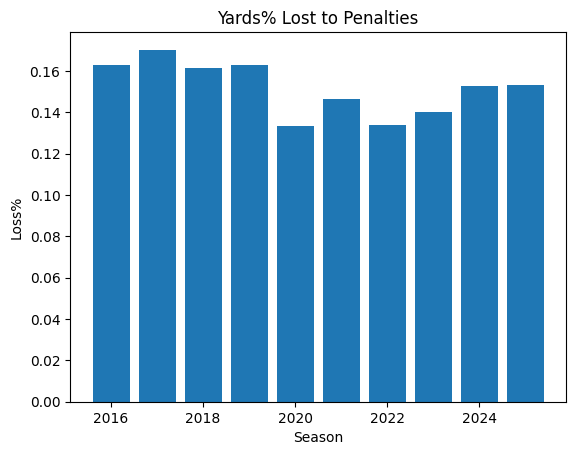

In [ ]:
pen_yards_lost = pbp.groupby(['season']).agg({"yards_gained": "sum",
                             'penalty_yards': 'sum'}).reset_index()

pen_yards_lost['pen_yards_lost'] = pen_yards_lost['penalty_yards'] / pen_yards_lost['yards_gained']


plt.bar(pen_yards_lost['season'], pen_yards_lost['pen_yards_lost'])
plt.title('Yards% Lost to Penalties')
plt.xlabel("Season")
plt.ylabel("Loss%")

plt.show()

In [ ]:
print("The average amount of yards gained per season from 2016-2025 is " + str(pen_yards_lost['yards_gained'].mean()) +
      """ yards. In the NFL, penalties usually take away a set
or variable number of yards from the team that commits them. For example, committing an Offensive False Start
causes the offense to lose 5 yards. The average amount of yards lost to penalties per season from 2016-2025 is """ +
      str(pen_yards_lost['penalty_yards'].mean()) + " yards.")

The average amount of yards gained per season from 2016-2025 is 189315.6 yards. In the NFL, penalties usually take away a set
or variable number of yards from the team that commits them. For example, committing an Offensive False Start
causes the offense to lose 5 yards. The average amount of yards lost to penalties per season from 2016-2025 is 28670.7 yards.


In [ ]:
standings = pd.read_csv("https://raw.githubusercontent.com/A-Peoples/NFL_Team_Penalties/refs/heads/main/standings.csv")

In [ ]:
standings = standings[['Tm', 'Team', 'W', 'L', 'T', 'W-L%', 'PF', 'PA',
       'PtDif', 'MoV', 'season']]

standings = standings.sort_values(by=['Team', 'season'])

standings

standings.to_csv('standings.csv')

In [ ]:
standings

,Tm,Team,W,L,T,W-L%,PF,PA,PtDif,MoV,season
0,Arizona Cardinals,ARI,7,8,1,0.469,418,362,56,3.5,2016
1,Arizona Cardinals,ARI,8,8,0,0.500,295,361,-66,-4.1,2017
2,Arizona Cardinals,ARI,3,13,0,0.188,225,425,-200,-12.5,2018
3,Arizona Cardinals,ARI,5,10,1,0.344,361,442,-81,-5.1,2019
4,Arizona Cardinals,ARI,8,8,0,0.500,410,367,43,2.7,2020
...,...,...,...,...,...,...,...,...,...,...,...
315,Washington Football Team,WAS,7,10,0,0.412,335,434,-99,-5.8,2021
316,Washington Commanders,WAS,8,8,1,0.500,321,343,-22,-1.3,2022
317,Washington Commanders,WAS,4,13,0,0.235,329,518,-189,-11.1,2023
318,Washington Commanders,WAS,12,5,0,0.706,485,391,94,5.5,2024


In [ ]:
#Creating a Linear Regression Model

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
import statsmodels.api as sm